# Notebook 2 : XGBoost

Cell 1 : Imports

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

os.makedirs("../data/models", exist_ok=True)
print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


Cell 2 : Loading Data

In [2]:
df = pd.read_csv("../data/processed/country_data.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df[["country_name", "gdp_per_capita", "ai_expansion_index", "sustainability_score"]].head(10))

Shape: (261, 11)
Columns: ['country_code', 'country_name', 'year', 'gdp_per_capita', 'energy_kwh_per_capita', 'co2_per_capita', 'renewable_pct', 'population', 'water_stress_pct', 'ai_expansion_index', 'sustainability_score']
                  country_name  gdp_per_capita  ai_expansion_index  \
0                        Aruba    35718.753119                 NaN   
1  Africa Eastern and Southern     1571.449189            0.029584   
2                  Afghanistan      413.757895                 NaN   
3   Africa Western and Central     1841.855064            0.000000   
4                       Angola     2916.136633            0.000000   
5                      Albania     9730.869219            0.141000   
6                      Andorra    46812.426101                 NaN   
7                   Arab World     7513.899079            0.151023   
8         United Arab Emirates    49850.687218            0.625748   
9                    Argentina    14261.846567            0.166912   

   s

Cell 3 : Feature Engineering

In [3]:
# Features the model uses to predict sustainability score
FEATURES = [
    "gdp_per_capita",
    "energy_kwh_per_capita",
    "renewable_pct",
    "water_stress_pct",
    "ai_expansion_index",
    "population"
]

TARGET = "sustainability_score"

# Fill remaining NaNs with column medians so XGBoost doesn't choke
df_model = df[FEATURES + [TARGET, "country_code", "country_name"]].copy()
for col in FEATURES:
    median_val = df_model[col].median()
    df_model[col] = df_model[col].fillna(median_val)

df_model = df_model.dropna(subset=[TARGET])

print(f"Training rows: {len(df_model)}")
print(df_model[FEATURES].describe().round(2))

Training rows: 261
       gdp_per_capita  energy_kwh_per_capita  renewable_pct  water_stress_pct  \
count          261.00                 261.00         261.00            261.00   
mean         20239.92                3546.93          29.68             91.60   
std          30692.37                4591.61          26.44            560.43   
min            250.63                  13.72           0.00              0.02   
25%           2591.97                1377.38           8.90              3.04   
50%           7887.54                2516.32          20.70              8.79   
75%          23785.75                4202.91          45.90             20.21   
max         256799.79               50951.22          96.30           7750.00   

       ai_expansion_index    population  
count              261.00  2.610000e+02  
mean                 0.17  3.031354e+08  
std                  0.19  9.912407e+08  
min                  0.00  9.816000e+03  
25%                  0.08  1.682668e+06  

Cell 4 : Training/Testing split

In [4]:
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (208, 6), Test: (53, 6)


Cell 5 : Training XGBoost model

In [5]:
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("Training complete")

[0]	validation_0-rmse:8.13546
[50]	validation_0-rmse:5.70545
[100]	validation_0-rmse:5.51832
[150]	validation_0-rmse:5.63114
[200]	validation_0-rmse:5.63998
[250]	validation_0-rmse:5.66072
[299]	validation_0-rmse:5.66623
Training complete


Cell 6 : Evaluate 

MAE  : 3.17  (average error in sustainability score points)
R²   : 0.5300  (1.0 = perfect, >0.85 is great for this task)


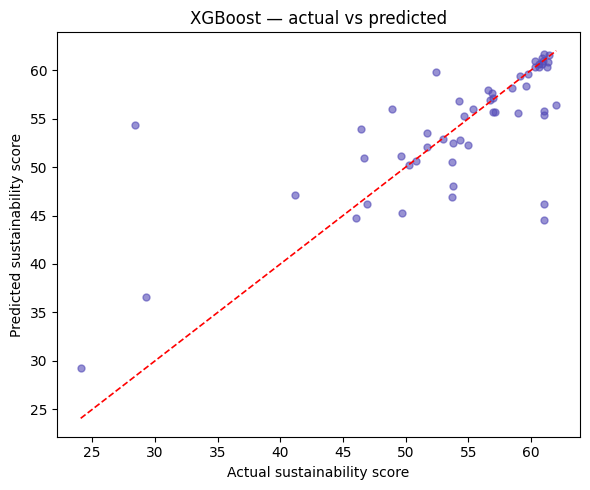

In [6]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}  (average error in sustainability score points)")
print(f"R²   : {r2:.4f}  (1.0 = perfect, >0.85 is great for this task)")

# Scatter: actual vs predicted
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color="#534AB7", s=25)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--", lw=1.2)
plt.xlabel("Actual sustainability score")
plt.ylabel("Predicted sustainability score")
plt.title("XGBoost — actual vs predicted")
plt.tight_layout()
plt.savefig("../data/processed/xgb_eval.png", dpi=120)
plt.show()

Cell 7 : Feature Importance

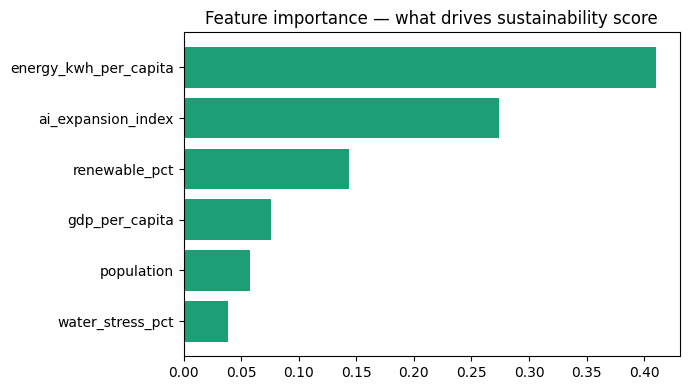

              feature  importance
energy_kwh_per_capita    0.410555
   ai_expansion_index    0.273480
        renewable_pct    0.143734
       gdp_per_capita    0.076271
           population    0.057383
     water_stress_pct    0.038576


In [7]:
importances = model.feature_importances_
feat_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": importances
}).sort_values("importance", ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(feat_df["feature"], feat_df["importance"], color="#1D9E75")
plt.title("Feature importance — what drives sustainability score")
plt.tight_layout()
plt.savefig("../data/processed/feature_importance.png", dpi=120)
plt.show()

print(feat_df.sort_values("importance", ascending=False).to_string(index=False))

Cell 8 : Predicting for all countries & build risk labels

In [8]:
df_model["predicted_score"] = model.predict(X)

def risk_label(score):
    if score >= 65:   return "Low risk"
    elif score >= 45: return "Moderate risk"
    elif score >= 25: return "High risk"
    else:             return "Critical risk"

df_model["risk_level"] = df_model["predicted_score"].apply(risk_label)

print(df_model[["country_name", "ai_expansion_index",
                "predicted_score", "risk_level"]].sort_values(
                "predicted_score", ascending=False).head(15).to_string(index=False))

            country_name  ai_expansion_index  predicted_score    risk_level
                  Tuvalu            0.105445        62.316669 Moderate risk
      Somalia, Fed. Rep.            0.105445        61.917381 Moderate risk
Central African Republic            0.105445        61.881100 Moderate risk
Northern Mariana Islands            0.105445        61.852119 Moderate risk
        Marshall Islands            0.105445        61.798038 Moderate risk
                   Niger            0.000000        61.795483 Moderate risk
                    Guam            0.105445        61.769249 Moderate risk
        Congo, Dem. Rep.            0.000000        61.736458 Moderate risk
           Faroe Islands            0.105445        61.729187 Moderate risk
                 Burundi            0.105445        61.701668 Moderate risk
              Madagascar            0.041556        61.700897 Moderate risk
                   Benin            0.000000        61.691971 Moderate risk
            

Cell 9 : Saving model + predictions 

In [9]:
# Save XGBoost model
with open("../data/models/xgb_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save feature list so the API loads it correctly
with open("../data/models/feature_list.pkl", "wb") as f:
    pickle.dump(FEATURES, f)

# Save full predictions table — the API will serve this
df_out = df_model[["country_code", "country_name",
                   "predicted_score", "risk_level",
                   "ai_expansion_index"] + FEATURES].copy()
df_out.to_csv("../data/processed/predictions.csv", index=False)

print("Saved: xgb_model.pkl, feature_list.pkl, predictions.csv")
print(f"Countries covered: {len(df_out)}")

Saved: xgb_model.pkl, feature_list.pkl, predictions.csv
Countries covered: 261
